# LUCJ + QPA + SQD — end-to-end on a simulator (2-spin demo)

Simulator-only, small-scale companion to [`lucj_qpa_depth.ipynb`](lucj_qpa_depth.ipynb). That notebook
costed the *resources* (qubits, gates, depth) of purity-amplifying a LUCJ-prepared chemistry state;
this one runs the **full workflow end to end** and quantifies the *benefit*. The structure mirrors
`end_to_end_unrolled_pittsburgh_t1.ipynb` (build circuits → inject depolarizing noise via Pauli
twirling → run → analyze a λ sweep), but the prepared state is the actual **LUCJ chemistry state**
and the downstream consumer is **SQD**, so the final figure of merit is a chemistry energy rather
than a fidelity-decay curve.

**The two pipelines compared at every noise strength λ:**

```
A (baseline):   LUCJ prep ──── λ noise ───────────────────────────────▶ measure Z ─▶ counts ─▶ SQD
B (QPA):        LUCJ prep ×N ─ λ noise (each copy) ─▶ swap-test amplifier
                                  └─▶ postselect schur = 0 ─▶ measure reserve ─▶ counts ─▶ SQD
```

**What does the output look like?** Both pipelines end in computational-basis bitstrings of one
`k = 2·norb`-qubit register — under Jordan–Wigner these are occupation-number strings (Slater
determinants), `(beta sector | alpha sector)` with qubit 0 rightmost. The ideal LUCJ state for the
stretched-H₂ demo below puts ~87% of its weight on the Hartree–Fock string `0101` and ~13% on the
doubly-excited string `1010`. Depolarizing noise λ does two things to that histogram: it **flattens**
it toward uniform, and — more damaging for chemistry — it leaks weight onto **symmetry-violating**
strings (wrong particle number per spin sector, e.g. `0000`, `1101`) that correspond to no valid
(1↑,1↓) determinant at all.

**How does QPA help?** QPA acts *before* measurement, at the quantum level: it takes N noisy copies
ρ_λ, runs swap tests between pairs, and the postselected reserve register carries a state of **higher
purity** than any input copy (for one all-pass round, exactly `(ρ + ρ²)/(1 + tr ρ²)` — derived and
plotted in Step 4). At the histogram level that means the accepted shots are *closer to the ideal
LUCJ distribution*: a larger fraction of symmetry-valid strings, and relative weights closer to the
true |amplitude|². The price is N× the qubits plus a postselection acceptance rate < 1.

**Should SQD be done here?** Yes — and it slots in exactly where the measurement happens. The only
thing this workflow takes from the purified register is computational-basis samples, which is
*precisely* the input SQD consumes (JW bitstrings → project H into the sampled determinant subspace →
classical diagonalization). So "LUCJ → SQD" vs "LUCJ+QPA → SQD" is the right end-to-end comparison:
QPA improves the **sample stream going in**, SQD turns whatever samples survive into an **energy
coming out**. Two honest caveats at this scale, both demonstrated below:

1. **(2e,2o) saturates SQD.** There are only 4 symmetry-valid determinants, so given enough shots the
   SQD subspace is complete and the energy lands on FCI *with or without* QPA. The QPA advantage at
   this scale lives in **sample quality** (TVD, valid fraction) and **sample efficiency** (the
   shot-starved regime of Step 8) — which is exactly what becomes an energy advantage at larger
   active spaces where the subspace is undersampled.
2. We deliberately **skip SQD's configuration-recovery loop** — at this size it would mask the very
   effect we want to isolate (it repairs corrupted bitstrings classically; QPA prevents them
   quantum-mechanically). Comparing/combining the two mitigation routes is a follow-up.

**Plan:** noiseless run first (λ = 0 sanity: both pipelines reproduce the ideal histogram and SQD hits
FCI), then a noisy λ sweep with the repo-standard Pauli-twirl emulation of register-level
depolarizing noise.

> **Dependencies:** `ffsim`, `pyscf`, and `qiskit-addon-sqd` (all in the `opqa` venv) on top of
> `qiskit` + `qiskit-aer`. Everything runs on `AerSimulator` — no IBM account needed.

In [1]:
# === repo-root bootstrap ===
import os, sys
os.environ["QISKIT_PARALLEL"] = "FALSE"   # avoid spawn-deadlock under nbconvert on macOS
_root = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(_root, "core")) and os.path.dirname(_root) != _root:
    _root = os.path.dirname(_root)
assert os.path.isdir(os.path.join(_root, "core")), "repo root (with core/) not found"
os.chdir(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)
print("Repo root:", _root)

import json
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from IPython.display import display

from pyscf import gto, scf, cc, fci, ao2mo
import ffsim

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import XGate, YGate, ZGate
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

from qiskit_addon_sqd.counts import counts_to_arrays
from qiskit_addon_sqd.subsampling import postselect_by_hamming_right_and_left
from qiskit_addon_sqd.fermion import solve_fermion

import qiskit
from importlib.metadata import version
print("qiskit", qiskit.__version__, "| qiskit-aer", version("qiskit-aer"),
      "| ffsim", version("ffsim"), "| qiskit-addon-sqd", version("qiskit-addon-sqd"))

Repo root: /Users/henryzou/Documents/GitHub/OQPA


qiskit 2.3.0 | qiskit-aer 0.17.2 | ffsim 0.0.80 | qiskit-addon-sqd 0.12.1


## Step 1: Configuration

| Parameter | Value | Notes |
|---|---|---|
| Molecule | H₂ at **1.5 Å**, STO-6G | stretched → strong correlation, so the LUCJ state has real structure |
| Active space | (2e, 2o) — the "2-spin" case | `norb = 2`, `k = 2·norb = 4` qubits per copy under JW |
| LUCJ | `n_reps = 1`, local pairs, t2-init + brief variational polish | polished so the *ansatz* isn't the error floor |
| QPA | `N = 3`, `T = 1` | 13 qubits total; postselect on the single Schur bit = 0 |
| Noise | global depolarizing strength λ per copy, Pauli-twirl emulation | repo-standard (`PauliTwirlingStrategy` semantics), injected **after** the LUCJ prep |
| λ sweep | 0.0 … 0.8 in steps of 0.1 | λ = 0 is the noiseless run |
| Sampling | 200 twirl instances × 10 shots per λ per pipeline | 2 000 raw shots per data point |
| Shot-starved SQD | batches of 12 raw shots × 100 batches | the regime where sample quality shows up as energy |

At equilibrium bond length the LUCJ ground state is ≈99.9% Hartree–Fock — nothing interesting to
sample. Stretching to 1.5 Å pushes ~13% of the weight onto the double excitation, which makes both
the sampling problem and the purification visible.

In [2]:
# ----- Chemistry: the "2-spin" / (2e,2o) case from lucj_qpa_depth.ipynb -----
R_BOND = 1.5                  # H-H distance (Angstrom)
BASIS  = "sto-6g"
NORB   = 2
NELEC  = (1, 1)               # (n_alpha, n_beta)
K      = 2 * NORB             # qubits per copy under Jordan-Wigner
N_REPS = 1                    # LUCJ layers

# ----- QPA amplifier -----
N_COPIES = 3
T_ROUNDS = 1
N_PAIRS  = (N_COPIES - 1) // 2

# ----- Noise & sampling -----
LAMBDAS = np.round(np.arange(0.0, 0.81, 0.1), 4)
N_TWIRL = 200                 # Pauli-twirl instances per lambda
SHOTS   = 10                  # shots per twirl instance
SEED    = 1234

# ----- Shot-starved SQD -----
S_BATCH   = 12                # raw readout shots per SQD batch
N_BATCHES = 400

CHEM_ACC = 1.6e-3             # chemical accuracy (Ha)

RESULTS_DIR = os.path.join("shared_data", "experiment_results", "lucj", "lucj_qpa_sqd_end_to_end")
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"(2e,2o) H2 @ {R_BOND} A | k={K} qubits/copy | QPA: N={N_COPIES}, T={T_ROUNDS} "
      f"({N_COPIES * K + N_PAIRS} qubits total)")
print(f"Lambda sweep: {LAMBDAS.tolist()}")
print(f"{N_TWIRL} twirls x {SHOTS} shots = {N_TWIRL * SHOTS} raw shots per (lambda, pipeline)")
print("Results ->", RESULTS_DIR)

(2e,2o) H2 @ 1.5 A | k=4 qubits/copy | QPA: N=3, T=1 (13 qubits total)
Lambda sweep: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
200 twirls x 10 shots = 2000 raw shots per (lambda, pipeline)
Results -> shared_data/experiment_results/lucj/lucj_qpa_sqd_end_to_end


## Step 2: Molecule and classical references

PySCF gives us the references everything is judged against: RHF (mean field), CCSD (source of the
LUCJ t2 amplitudes), and FCI (exact in this basis — the target). We also pull the one- and two-body
integrals in the MO basis, which is what SQD diagonalizes against later.

In [3]:
mol = gto.M(atom=f"H 0 0 0; H 0 0 {R_BOND}", basis=BASIS, verbose=0)
mf = scf.RHF(mol).run()
ccsd = cc.CCSD(mf).run(verbose=0)
E_FCI = fci.FCI(mf).kernel()[0]
E_NUC = mol.energy_nuc()

# Integrals in the MO basis (the Hamiltonian SQD projects & diagonalizes)
HCORE_MO = mf.mo_coeff.T @ mf.get_hcore() @ mf.mo_coeff
ERI_MO = ao2mo.restore(1, ao2mo.kernel(mol, mf.mo_coeff), NORB)

print(f"E_HF   = {mf.e_tot:.6f} Ha")
print(f"E_CCSD = {ccsd.e_tot:.6f} Ha")
print(f"E_FCI  = {E_FCI:.6f} Ha   (correlation energy: {1000*(E_FCI - mf.e_tot):.2f} mHa)")
print(f"HF error vs FCI: {1000*(mf.e_tot - E_FCI):.2f} mHa  "
      f"(~{(mf.e_tot - E_FCI)/CHEM_ACC:.0f}x chemical accuracy -> correlation matters here)")

E_HF   = -0.918936 Ha
E_CCSD = -1.006563 Ha
E_FCI  = -1.006563 Ha   (correlation energy: -87.63 mHa)
HF error vs FCI: 87.63 mHa  (~55x chemical accuracy -> correlation matters here)


## Step 3: The LUCJ state

Same ansatz structure as `lucj_qpa_depth.ipynb` (`n_reps = 1`, nearest-neighbour same-spin +
on-site opposite-spin interaction pairs), but with **meaningful parameters**: initialized from the
CCSD t2 amplitudes (the standard SQD/LUCJ workflow) and then polished with a short L-BFGS-B
statevector optimization. The polish matters for a clean demo — the raw t2-derived ansatz sits
~49 mHa above FCI at this stretched geometry, which would blur the line between *ansatz* error and
*noise* error. After polishing, the LUCJ state **is** the FCI ground state (to numerical precision),
so any deviation we see downstream is attributable to noise, sampling, or QPA.

The ideal measurement histogram of this state is the reference distribution for every comparison
below.

E_LUCJ (t2 init) = -0.957818 Ha  (+48.74 mHa vs FCI)
E_LUCJ (polished) = -1.006563 Ha  (+0.00 mHa vs FCI, 108 evals)

Symmetry-valid determinants (4 of 16 bitstrings): ['0101', '0110', '1001', '1010']
Ideal LUCJ histogram: {'0101': 0.873, '1010': 0.127}


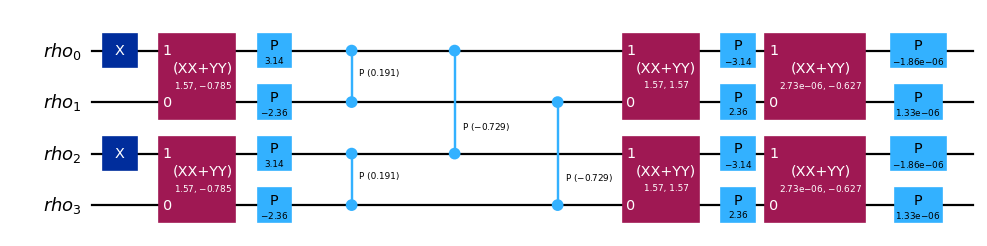

In [4]:
PAIRS_AA = [(p, p + 1) for p in range(NORB - 1)]   # nearest-neighbour, same spin
PAIRS_AB = [(p, p) for p in range(NORB)]           # on-site, opposite spin

op_init = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    ccsd.t2, t1=ccsd.t1, n_reps=N_REPS, interaction_pairs=(PAIRS_AA, PAIRS_AB))

ham_ffsim = ffsim.MolecularData.from_scf(mf).hamiltonian
LINOP = ffsim.linear_operator(ham_ffsim, norb=NORB, nelec=NELEC)
HF_VEC = ffsim.hartree_fock_state(NORB, NELEC)

def lucj_energy(x):
    op = ffsim.UCJOpSpinBalanced.from_parameters(
        x, norb=NORB, n_reps=N_REPS, interaction_pairs=(PAIRS_AA, PAIRS_AB),
        with_final_orbital_rotation=True)
    vec = ffsim.apply_unitary(HF_VEC, op, norb=NORB, nelec=NELEC)
    return np.real(np.vdot(vec, LINOP @ vec))

x0 = op_init.to_parameters(interaction_pairs=(PAIRS_AA, PAIRS_AB))
E_LUCJ_INIT = lucj_energy(x0)
res = minimize(lucj_energy, x0, method="L-BFGS-B", options={"maxiter": 500})
UCJ_OP = ffsim.UCJOpSpinBalanced.from_parameters(
    res.x, norb=NORB, n_reps=N_REPS, interaction_pairs=(PAIRS_AA, PAIRS_AB),
    with_final_orbital_rotation=True)
E_LUCJ = res.fun

print(f"E_LUCJ (t2 init) = {E_LUCJ_INIT:.6f} Ha  ({1000*(E_LUCJ_INIT - E_FCI):+.2f} mHa vs FCI)")
print(f"E_LUCJ (polished) = {E_LUCJ:.6f} Ha  ({1000*(E_LUCJ - E_FCI):+.2f} mHa vs FCI, {res.nfev} evals)")

# --- the state-prep circuit and its ideal histogram ---
PREP = QuantumCircuit(QuantumRegister(K, "rho"))
PREP.append(ffsim.qiskit.PrepareHartreeFockJW(NORB, NELEC), PREP.qubits)
PREP.append(ffsim.qiskit.UCJOpSpinBalancedJW(UCJ_OP), PREP.qubits)

IDEAL_SV = Statevector(PREP)
IDEAL_DIST = IDEAL_SV.probabilities()          # index i <-> bitstring format(i, '04b')

# Symmetry-valid bitstrings: correct Hamming weight per spin sector.
# JW/ffsim convention: qubits 0..norb-1 = alpha (right end of the string), norb..2norb-1 = beta (left end).
ALL_STRINGS = [format(i, f"0{K}b") for i in range(2 ** K)]
def is_valid(b):
    return b[-NORB:].count("1") == NELEC[0] and b[:NORB].count("1") == NELEC[1]
VALID_STRINGS = [b for b in ALL_STRINGS if is_valid(b)]
VALID_IDX = np.array([int(b, 2) for b in VALID_STRINGS])

print(f"\nSymmetry-valid determinants ({len(VALID_STRINGS)} of {2**K} bitstrings): {VALID_STRINGS}")
print("Ideal LUCJ histogram:",
      {b: round(float(IDEAL_DIST[int(b, 2)]), 4) for b in ALL_STRINGS if IDEAL_DIST[int(b, 2)] > 1e-9})
display(PREP.decompose(reps=2).draw("mpl", fold=-1, scale=0.8))

## Step 4: Exact small-scale theory — what QPA should deliver

At 4 qubits per copy we can write everything down exactly with 16×16 matrices, which gives us
parameter-free theory curves to validate the circuit results against.

Each copy entering the amplifier is the globally-depolarized state
$\rho_\lambda = (1-\lambda)\,|\psi\rangle\langle\psi| + \lambda\, I/d$, $d = 2^k = 16$.
For `N = 3, T = 1`, one swap test on copies (R1, R2) projects onto the symmetric subspace
$\Pi = (I + S)/2$; conditioned on **pass** (Schur bit = 0) the register that ends up measured carries

$$\rho_{\text{out}} = \frac{\rho_\lambda + \rho_\lambda^2}{1 + \mathrm{tr}\,\rho_\lambda^2},
\qquad p_{\text{accept}} = \frac{1 + \mathrm{tr}\,\rho_\lambda^2}{2}.$$

This is the canonical purification map: it boosts the dominant eigenvector ($|\psi\rangle$) and
suppresses the noise floor. From these two formulas we get exact predictions for **everything we
measure below** — fidelity, acceptance rate, the full readout histogram (its diagonal), hence the
TVD to ideal and the symmetry-valid fraction. Fidelity itself isn't observable from Z-basis counts
alone; TVD and valid fraction are its measurable proxies here.

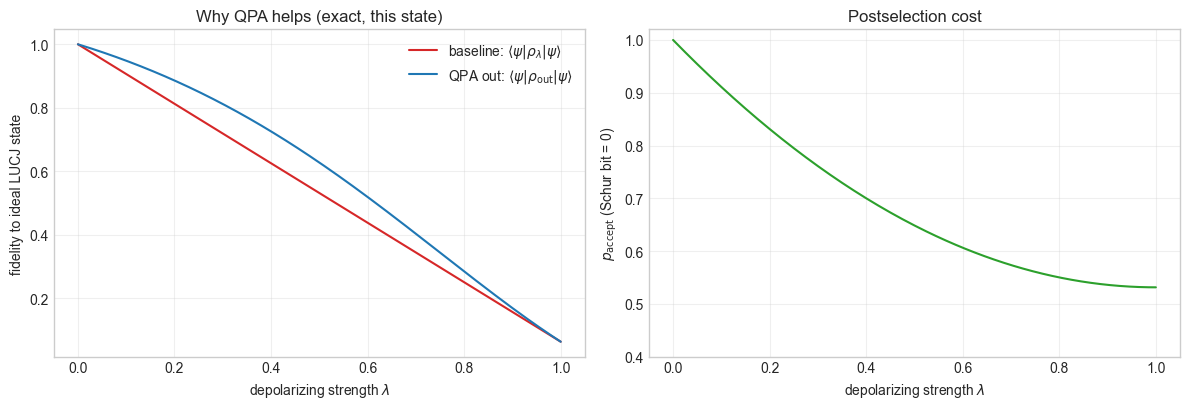

At lambda=0.5: fidelity 0.531 -> 0.627 (one QPA round, acceptance 0.65)


In [5]:
D = 2 ** K
PSI = IDEAL_SV.data
RHO_IDEAL = np.outer(PSI, PSI.conj())

def rho_depol(lam):
    return (1 - lam) * RHO_IDEAL + lam * np.eye(D) / D

def qpa_output(rho):
    r2 = rho @ rho
    return (rho + r2) / (1 + np.trace(r2).real)

def acceptance_theory(lam):
    rho = rho_depol(lam)
    return (1 + np.trace(rho @ rho).real) / 2

def fidelity_to_ideal(rho):
    return float(np.real(PSI.conj() @ rho @ PSI))

def dist_theory(lam, pipeline):
    rho = rho_depol(lam)
    if pipeline == "qpa":
        rho = qpa_output(rho)
    return np.real(np.diag(rho))

def tvd(p, q):
    return 0.5 * float(np.abs(np.asarray(p) - np.asarray(q)).sum())

lam_fine = np.linspace(0, 1, 201)
F_base_th = np.array([fidelity_to_ideal(rho_depol(l)) for l in lam_fine])
F_qpa_th  = np.array([fidelity_to_ideal(qpa_output(rho_depol(l))) for l in lam_fine])
acc_th    = np.array([acceptance_theory(l) for l in lam_fine])

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(lam_fine, F_base_th, "-", color="tab:red", label=r"baseline: $\langle\psi|\rho_\lambda|\psi\rangle$")
ax[0].plot(lam_fine, F_qpa_th, "-", color="tab:blue", label=r"QPA out: $\langle\psi|\rho_{\rm out}|\psi\rangle$")
ax[0].set_xlabel(r"depolarizing strength $\lambda$"); ax[0].set_ylabel("fidelity to ideal LUCJ state")
ax[0].set_title("Why QPA helps (exact, this state)"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(lam_fine, acc_th, "-", color="tab:green")
ax[1].set_xlabel(r"depolarizing strength $\lambda$"); ax[1].set_ylabel(r"$p_{\rm accept}$ (Schur bit = 0)")
ax[1].set_title("Postselection cost"); ax[1].set_ylim(0.4, 1.02); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

i_mid = np.argmin(np.abs(lam_fine - 0.5))
print(f"At lambda=0.5: fidelity {F_base_th[i_mid]:.3f} -> {F_qpa_th[i_mid]:.3f} "
      f"(one QPA round, acceptance {acc_th[i_mid]:.2f})")

## Step 5: The circuits — baseline and QPA instances

Same construction as `lucj_qpa_depth.ipynb`'s `build_qpa_lucj`, with two changes for an *executable*
experiment rather than a depth estimate:

1. **Every copy gets the same (polished) LUCJ parameters** — QPA needs N identical copies of ρ (the
   depth notebook used different seeds per register, which was fine for counting gates).
2. **Noise is injected after the prep, before the amplifier**, per copy — emulating each copy
   independently traversing a depolarizing channel of strength λ. Implementation is the repo-standard
   Pauli-twirl: with probability λ, hit the register with a uniformly random k-qubit Pauli string;
   averaged over many instances this is exactly $\rho \mapsto (1-\lambda)\rho + \lambda I/d$
   (same semantics as `core.noise_models.PauliTwirlingStrategy`, inlined here since we insert into
   untranspiled circuits). Statevector simulation stays cheap because every instance is pure.

The amplifier is the longest-path cyclic QPA: `H · CSWAP^k · H` swap test on (R1, R2), measure+reset
the ancilla, cyclic rotation of all registers, measure the reserve register into `readout`.
Postselection keeps shots with the Schur bit(s) = 0 (the all-pass branch). The LUCJ block is
pre-transpiled to Aer's basis once and composed into every instance.

LUCJ block (Aer basis): {'rxx': 4, 'ryy': 4, 'p': 4, 'cp': 4, 'x': 2, 'rz': 2, 'u1': 2}


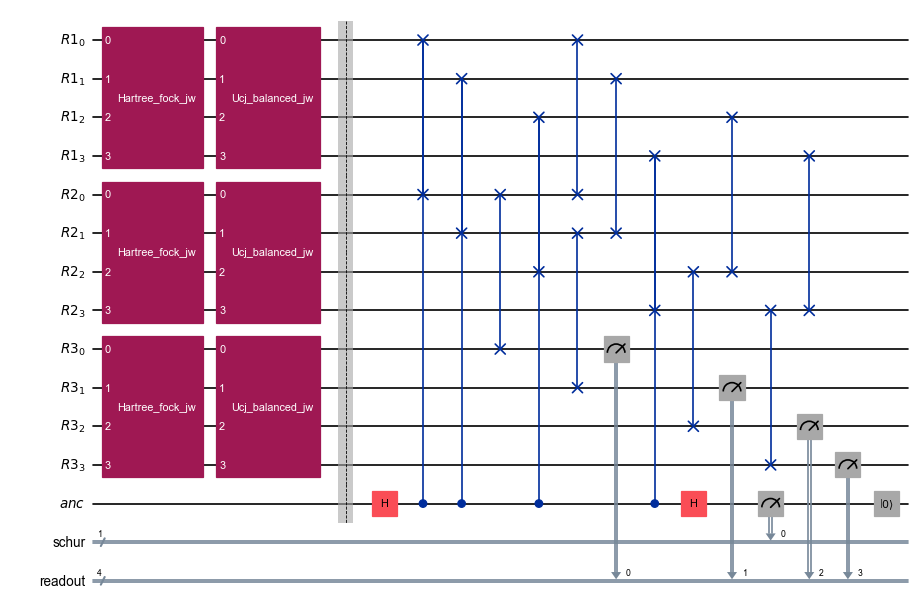

In [6]:
SIM = AerSimulator(seed_simulator=SEED)
PREP_AER = transpile(PREP, SIM)   # decompose ffsim blocks once; reused by every instance
print("LUCJ block (Aer basis):", dict(PREP_AER.count_ops()))

PAULI_GATES = [None, XGate(), YGate(), ZGate()]

def apply_register_depolarizing(qc, reg, lam, rng):
    '''With prob lam, apply a uniformly random k-qubit Pauli string (incl. identity) to reg.
    Instance-averaged: rho -> (1-lam) rho + lam I/2^k (global depolarizing on the register).'''
    if lam <= 0 or rng.random() >= lam:
        return
    for q in reg:
        g = PAULI_GATES[rng.integers(4)]
        if g is not None:
            qc.append(g, [q])

def baseline_instance(lam, rng, prep_block=None):
    qr = QuantumRegister(K, "R1")
    cr = ClassicalRegister(K, "readout")
    qc = QuantumCircuit(qr, cr)
    qc.compose(prep_block if prep_block is not None else PREP_AER, qubits=qr, inplace=True)
    apply_register_depolarizing(qc, qr, lam, rng)
    qc.measure(qr, cr)
    return qc

def qpa_instance(lam, rng, prep_block=None):
    data = [QuantumRegister(K, f"R{i+1}") for i in range(N_COPIES)]
    anc = QuantumRegister(N_PAIRS, "anc")
    cr_s = ClassicalRegister(T_ROUNDS * N_PAIRS, "schur")
    cr_o = ClassicalRegister(K, "readout")
    qc = QuantumCircuit(*data, anc, cr_s, cr_o)
    for reg in data:                                   # N identical LUCJ copies
        qc.compose(prep_block if prep_block is not None else PREP_AER, qubits=reg, inplace=True)
    for reg in data:                                   # independent depolarizing per copy
        apply_register_depolarizing(qc, reg, lam, rng)
    qc.barrier()
    m = 0
    for _t in range(T_ROUNDS):
        for i in range(N_PAIRS):                       # swap tests (controlled-P = CSWAP^k)
            a, ra, rb = anc[i], data[2 * i], data[2 * i + 1]
            qc.h(a)
            for b in range(K):
                qc.cswap(a, ra[b], rb[b])
            qc.h(a)
            qc.measure(a, cr_s[m]); m += 1
            qc.reset(a)
        for b in range(K):                             # cyclic rotation (uncontrolled P)
            for j in range(N_COPIES - 1, 0, -1):
                qc.swap(data[j][b], data[j - 1][b])
    qc.measure(data[-1], cr_o)
    return qc

def merge_counts(counts_list):
    out = defaultdict(int)
    for c in counts_list:
        for key, v in c.items():
            out[key] += v
    return dict(out)

def _run(circuits, shots):
    counts = SIM.run(circuits, shots=shots).result().get_counts()
    return counts if isinstance(counts, list) else [counts]

def run_baseline(lam, rng, n_twirl=N_TWIRL, shots=SHOTS):
    '''Aggregated readout counts for pipeline A at noise strength lam.'''
    if lam == 0.0:   # no randomness in the circuit -> one instance, all shots
        circs, shots = [baseline_instance(0.0, rng)], n_twirl * shots
    else:
        circs = [baseline_instance(lam, rng) for _ in range(n_twirl)]
    return merge_counts(_run(circs, shots))

def run_qpa(lam, rng, n_twirl=N_TWIRL, shots=SHOTS):
    '''Aggregated postselected readout counts + acceptance rate for pipeline B.'''
    if lam == 0.0:
        circs, shots = [qpa_instance(0.0, rng)], n_twirl * shots
    else:
        circs = [qpa_instance(lam, rng) for _ in range(n_twirl)]
    raw = merge_counts(_run(circs, shots))
    accepted = defaultdict(int)
    total = sum(raw.values())
    for key, c in raw.items():
        readout, schur = key.split()                   # creg order: 'readout schur'
        if schur == "0" * len(schur):
            accepted[readout] += c
    return dict(accepted), sum(accepted.values()) / total

def counts_to_dist(counts):
    p = np.zeros(2 ** K)
    total = sum(counts.values())
    for b, c in counts.items():
        p[int(b, 2)] += c / total
    return p

# A look at one QPA instance (high-level LUCJ blocks, noiseless)
display(qpa_instance(0.0, np.random.default_rng(0), prep_block=PREP).draw("mpl", fold=-1, scale=0.6))

## Step 6: Noiseless run (λ = 0) — sanity check

With λ = 0 all three copies are the identical *pure* LUCJ state, so the swap test passes with
probability 1 (acceptance = 1, no shots discarded) and the QPA readout histogram must match the
baseline histogram must match the ideal |amplitude|² distribution, up to shot noise. This validates
the whole circuit construction — prep, amplifier wiring, postselection bookkeeping, register
conventions — before any noise enters.

In [7]:
rng0 = np.random.default_rng(SEED)
counts_base_0 = run_baseline(0.0, rng0)
counts_qpa_0, acc_0 = run_qpa(0.0, rng0)

dist_b0, dist_q0 = counts_to_dist(counts_base_0), counts_to_dist(counts_qpa_0)
n_b0, n_q0 = sum(counts_base_0.values()), sum(counts_qpa_0.values())

print(f"{'bitstring':>10} {'ideal':>8} {'baseline':>9} {'QPA':>8}")
for b in sorted(ALL_STRINGS, key=lambda s: -IDEAL_DIST[int(s, 2)]):
    i = int(b, 2)
    if IDEAL_DIST[i] > 1e-9 or dist_b0[i] > 0 or dist_q0[i] > 0:
        print(f"{b:>10} {IDEAL_DIST[i]:>8.4f} {dist_b0[i]:>9.4f} {dist_q0[i]:>8.4f}")
print(f"\nTVD to ideal:  baseline = {tvd(dist_b0, IDEAL_DIST):.4f},  QPA = {tvd(dist_q0, IDEAL_DIST):.4f}"
      f"   (shot-noise floor ~{0.5 * np.sqrt(2 / n_b0):.3f} with {n_b0} shots)")
print(f"QPA acceptance = {acc_0:.4f}  (theory: {acceptance_theory(0.0):.4f})")
assert acc_0 > 0.99 and tvd(dist_b0, dist_q0) < 0.05, "noiseless sanity check failed"
print("Noiseless sanity check passed.")

 bitstring    ideal  baseline      QPA
      0101   0.8730    0.8745   0.8745
      1010   0.1270    0.1255   0.1255

TVD to ideal:  baseline = 0.0015,  QPA = 0.0015   (shot-noise floor ~0.016 with 2000 shots)
QPA acceptance = 1.0000  (theory: 1.0000)
Noiseless sanity check passed.


## Step 7: SQD on the samples

The SQD step (via `qiskit-addon-sqd`): aggregate counts → unique bitstrings → **postselect** on the
correct Hamming weight per spin sector (1↑, 1↓) → project the Hamiltonian into the CI space spanned
by the sampled determinants (the addon takes the α-string × β-string cross product) → diagonalize
classically (`solve_fermion`, electronic energy + nuclear repulsion).

Note what SQD is *for*: a quantum-sampled selected-CI. The circuit proposes *which determinants
matter*; the classical eigensolver gets the energy variationally within that subspace. That's why it
pairs so naturally with QPA — it only needs the Z-basis samples QPA's reserve register produces, and
its accuracy is set by whether the *right determinants* show up in the (limited) sample budget.

On the noiseless samples both pipelines should land on FCI: the two sampled configurations `0101`
and `1010` give α-strings {01, 10} × β-strings {01, 10} = all 4 valid determinants — the full CI
space. (This is the saturation caveat from the intro in action: SQD can even land *below* the raw
ansatz energy, because diagonalization in the sampled subspace is better than the ansatz expectation
value.)

In [8]:
def sqd_energy(counts):
    '''SQD energy (Ha, incl. nuclear repulsion) from readout counts.
    Returns (energy, n_unique_valid_determinants); (nan, 0) if no valid determinant sampled.'''
    if not counts:
        return np.nan, 0
    bs_mat, probs = counts_to_arrays(counts)
    bs_valid, _ = postselect_by_hamming_right_and_left(
        bs_mat, probs, hamming_right=NELEC[0], hamming_left=NELEC[1])
    if len(bs_valid) == 0:
        return np.nan, 0
    e_elec, _sci_state, _occs, _spin = solve_fermion(
        bs_valid, HCORE_MO, ERI_MO, open_shell=False, spin_sq=0.0)
    return e_elec + E_NUC, len(bs_valid)

e_b0, ndet_b0 = sqd_energy(counts_base_0)
e_q0, ndet_q0 = sqd_energy(counts_qpa_0)
print(f"E_FCI                  = {E_FCI:.6f} Ha")
print(f"E_LUCJ (statevector)   = {E_LUCJ:.6f} Ha")
print(f"SQD, baseline samples  = {e_b0:.6f} Ha  ({1000*(e_b0 - E_FCI):+.4f} mHa vs FCI, {ndet_b0} unique valid dets)")
print(f"SQD, QPA samples       = {e_q0:.6f} Ha  ({1000*(e_q0 - E_FCI):+.4f} mHa vs FCI, {ndet_q0} unique valid dets)")

E_FCI                  = -1.006563 Ha
E_LUCJ (statevector)   = -1.006563 Ha
SQD, baseline samples  = -1.006563 Ha  (-0.0000 mHa vs FCI, 2 unique valid dets)
SQD, QPA samples       = -1.006563 Ha  (-0.0000 mHa vs FCI, 2 unique valid dets)


## Step 8: Noisy sweep — λ = 0.0 … 0.8

For every λ we run both pipelines (200 twirl instances × 10 shots each) and record, against the
exact theory of Step 4:

- **acceptance rate** (QPA) — the postselection cost;
- **TVD to the ideal histogram** — overall sample quality;
- **symmetry-valid fraction** — the chemistry-relevant slice of sample quality;
- **full-sample SQD energy** — expected to stay ≈FCI for *both* pipelines (subspace saturation).

Aggregated counts are also kept for the shot-starved analysis of Step 9, and everything is written
to `summary.csv` / `counts.json` in the results directory.

In [9]:
sweep_rows = []
counts_store = {}

print(f"{'lam':>4} | {'acc':>6} {'(th)':>6} | {'TVD base':>8} {'(th)':>6} | {'TVD QPA':>8} {'(th)':>6} | "
      f"{'valid b':>7} {'valid q':>7} | {'SQD b-FCI':>10} {'SQD q-FCI':>10} (mHa)")
for lam in LAMBDAS:
    rng_l = np.random.default_rng(SEED + int(round(lam * 1000)))
    cb = run_baseline(lam, rng_l)
    cq, acc_emp = run_qpa(lam, rng_l)
    counts_store[float(lam)] = {"baseline": cb, "qpa": cq}

    pb, pq = counts_to_dist(cb), counts_to_dist(cq)
    e_b, ndet_b = sqd_energy(cb)
    e_q, ndet_q = sqd_energy(cq)

    row = dict(
        lam=float(lam),
        acc_emp=acc_emp, acc_th=acceptance_theory(lam),
        tvd_base=tvd(pb, IDEAL_DIST), tvd_base_th=tvd(dist_theory(lam, "baseline"), IDEAL_DIST),
        tvd_qpa=tvd(pq, IDEAL_DIST), tvd_qpa_th=tvd(dist_theory(lam, "qpa"), IDEAL_DIST),
        valid_base=float(pb[VALID_IDX].sum()), valid_base_th=float(dist_theory(lam, "baseline")[VALID_IDX].sum()),
        valid_qpa=float(pq[VALID_IDX].sum()), valid_qpa_th=float(dist_theory(lam, "qpa")[VALID_IDX].sum()),
        e_sqd_base=e_b, ndet_base=ndet_b, e_sqd_qpa=e_q, ndet_qpa=ndet_q,
    )
    sweep_rows.append(row)
    print(f"{lam:>4.1f} | {acc_emp:>6.3f} {row['acc_th']:>6.3f} | {row['tvd_base']:>8.3f} {row['tvd_base_th']:>6.3f} | "
          f"{row['tvd_qpa']:>8.3f} {row['tvd_qpa_th']:>6.3f} | {row['valid_base']:>7.3f} {row['valid_qpa']:>7.3f} | "
          f"{1000*(e_b - E_FCI):>10.4f} {1000*(e_q - E_FCI):>10.4f}")

df = pd.DataFrame(sweep_rows)
df.to_csv(os.path.join(RESULTS_DIR, "summary.csv"), index=False)
with open(os.path.join(RESULTS_DIR, "counts.json"), "w") as f:
    json.dump({str(l): c for l, c in counts_store.items()}, f)
print("\nSaved summary.csv and counts.json ->", RESULTS_DIR)

 lam |    acc   (th) | TVD base   (th) |  TVD QPA   (th) | valid b valid q |  SQD b-FCI  SQD q-FCI (mHa)
 0.0 |  1.000  1.000 |    0.001  0.000 |    0.001  0.000 |   1.000   1.000 |    -0.0000    -0.0000


 0.1 |  0.922  0.911 |    0.085  0.087 |    0.038  0.048 |   0.920   0.973 |    -0.0000    -0.0000


 0.2 |  0.842  0.831 |    0.175  0.175 |    0.108  0.107 |   0.840   0.911 |    -0.0000    -0.0000


 0.3 |  0.761  0.761 |    0.335  0.262 |    0.171  0.176 |   0.710   0.856 |    -0.0000    -0.0000


 0.4 |  0.725  0.700 |    0.340  0.350 |    0.256  0.256 |   0.685   0.779 |    -0.0000    -0.0000


 0.5 |  0.640  0.648 |    0.440  0.437 |    0.326  0.348 |   0.610   0.745 |    -0.0000    -0.0000


 0.6 |  0.611  0.606 |    0.550  0.525 |    0.443  0.449 |   0.535   0.636 |    -0.0000    -0.0000


 0.7 |  0.574  0.573 |    0.580  0.612 |    0.513  0.557 |   0.465   0.564 |    -0.0000    -0.0000


 0.8 |  0.555  0.550 |    0.665  0.700 |    0.613  0.668 |   0.435   0.487 |    -0.0000    -0.0000

Saved summary.csv and counts.json -> shared_data/experiment_results/lucj/lucj_qpa_sqd_end_to_end


## Step 9: Shot-starved SQD — where sample quality becomes energy

As predicted, the full-sample SQD energies saturate: with 2 000 shots, all 4 valid determinants show
up for both pipelines at every λ, the CI space is complete, and the energy is FCI regardless of
noise. **At this system size, energy alone cannot distinguish the pipelines** — that's a statement
about (2e,2o), not about QPA.

The regime where sample quality *does* become energy is the **shot-starved** one — which is also the
realistic regime at scale, where shots-per-determinant is always scarce. Here we hand SQD small
batches of `S_BATCH = 12` raw readout shots (drawn multinomially from each pipeline's measured
histogram), postselect within the batch, and diagonalize in whatever subspace survives. A batch
whose valid samples don't cover both α-strings *and* both β-strings (most commonly: no `1010`-type
sample) lands well above FCI — up to the ~88 mHa Hartree–Fock error; a batch with no valid string at
all is a total failure. The table below reports mean ± std of the energy error over 400 batches
plus the failure rate (the per-batch error distribution is bimodal — ≈0 or ≈the missing-determinant
penalty — so the plot in Step 10 shows the mean ± its standard error instead).

**Read this plot with two effects in mind**, both quantified below and both honest features of the
(2e,2o) scale:

- *Where QPA helps:* at low-to-moderate λ, QPA's histogram keeps more weight on the correct valid
  determinants per accepted shot, so fewer batches miss the correlated configuration → lower mean
  error.
- *Where the tiny system flatters the baseline:* depolarizing noise spreads weight onto **all**
  strings — and at (2e,2o), 4 of the 16 strings happen to be valid determinants. So strong noise
  *spuriously repopulates* determinants a starved batch would otherwise miss, partially rescuing the
  baseline's energy even as its histogram (top panels) degrades badly. This "noise as accidental
  configuration recovery" is an artifact of the tiny space: at scale, a random string is
  exponentially unlikely to be a valid determinant, and this rescue vanishes while QPA's
  distribution-level advantage remains. It's the clearest demonstration in this notebook of *why*
  the energy metric under-reports both the damage of noise and the benefit of QPA at (2e,2o).

(Per-batch comparison is at equal *accepted* readout samples; QPA additionally pays the acceptance
factor of Step 4 plus N× qubits to *produce* each accepted sample — the honest hardware cost.)

In [10]:
def starved_sqd(counts, rng, s_batch=S_BATCH, n_batches=N_BATCHES):
    keys = list(counts)
    p = np.array([counts[k] for k in keys], dtype=float)
    p /= p.sum()
    errs, misses = [], 0
    for _ in range(n_batches):
        draw = rng.multinomial(s_batch, p)
        batch = {k: int(n) for k, n in zip(keys, draw) if n > 0}
        e, ndet = sqd_energy(batch)
        if ndet == 0:
            misses += 1
            continue
        errs.append(e - E_FCI)
    errs = np.array(errs)
    return dict(mean=errs.mean() if errs.size else np.nan,
                std=errs.std() if errs.size else np.nan,
                miss_rate=misses / n_batches)

rng_b = np.random.default_rng(SEED + 7)
starved_rows = []
print(f"{'lam':>4} | {'baseline err (mHa)':>22} {'miss':>5} | {'QPA err (mHa)':>22} {'miss':>5}")
for lam in LAMBDAS:
    sb = starved_sqd(counts_store[float(lam)]["baseline"], rng_b)
    sq = starved_sqd(counts_store[float(lam)]["qpa"], rng_b)
    starved_rows.append(dict(lam=float(lam),
        starved_base_mean=sb["mean"], starved_base_std=sb["std"], starved_base_miss=sb["miss_rate"],
        starved_qpa_mean=sq["mean"], starved_qpa_std=sq["std"], starved_qpa_miss=sq["miss_rate"]))
    print(f"{lam:>4.1f} | {1000*sb['mean']:>10.2f} +/- {1000*sb['std']:>7.2f} {sb['miss_rate']:>5.2f} | "
          f"{1000*sq['mean']:>10.2f} +/- {1000*sq['std']:>7.2f} {sq['miss_rate']:>5.2f}")

df = df.merge(pd.DataFrame(starved_rows), on="lam")
df.to_csv(os.path.join(RESULTS_DIR, "summary.csv"), index=False)
print("\nUpdated summary.csv with shot-starved columns.")

 lam |     baseline err (mHa)  miss |          QPA err (mHa)  miss


 0.0 |      17.31 +/-   34.89  0.00 |      17.31 +/-   34.89  0.00


 0.1 |      18.40 +/-   35.69  0.00 |      12.92 +/-   31.07  0.00


 0.2 |      16.43 +/-   34.20  0.00 |      15.55 +/-   33.48  0.00


 0.3 |      15.77 +/-   33.67  0.00 |      15.33 +/-   33.30  0.00


 0.4 |      15.55 +/-   33.48  0.00 |      14.90 +/-   32.92  0.00


 0.5 |      12.92 +/-   31.07  0.00 |       8.32 +/-   25.69  0.00


 0.6 |      12.96 +/-   31.10  0.00 |       6.13 +/-   22.36  0.00


 0.7 |      11.61 +/-   29.71  0.00 |      12.27 +/-   30.41  0.00


 0.8 |      13.88 +/-   70.00  0.00 |       7.64 +/-   37.23  0.00

Updated summary.csv with shot-starved columns.


## Step 10: The picture

Four panels, λ on every x-axis. Solid lines are the *exact* theory of Step 4 (no fit parameters);
markers are the simulator. Red = baseline (pipeline A), blue = QPA (pipeline B).

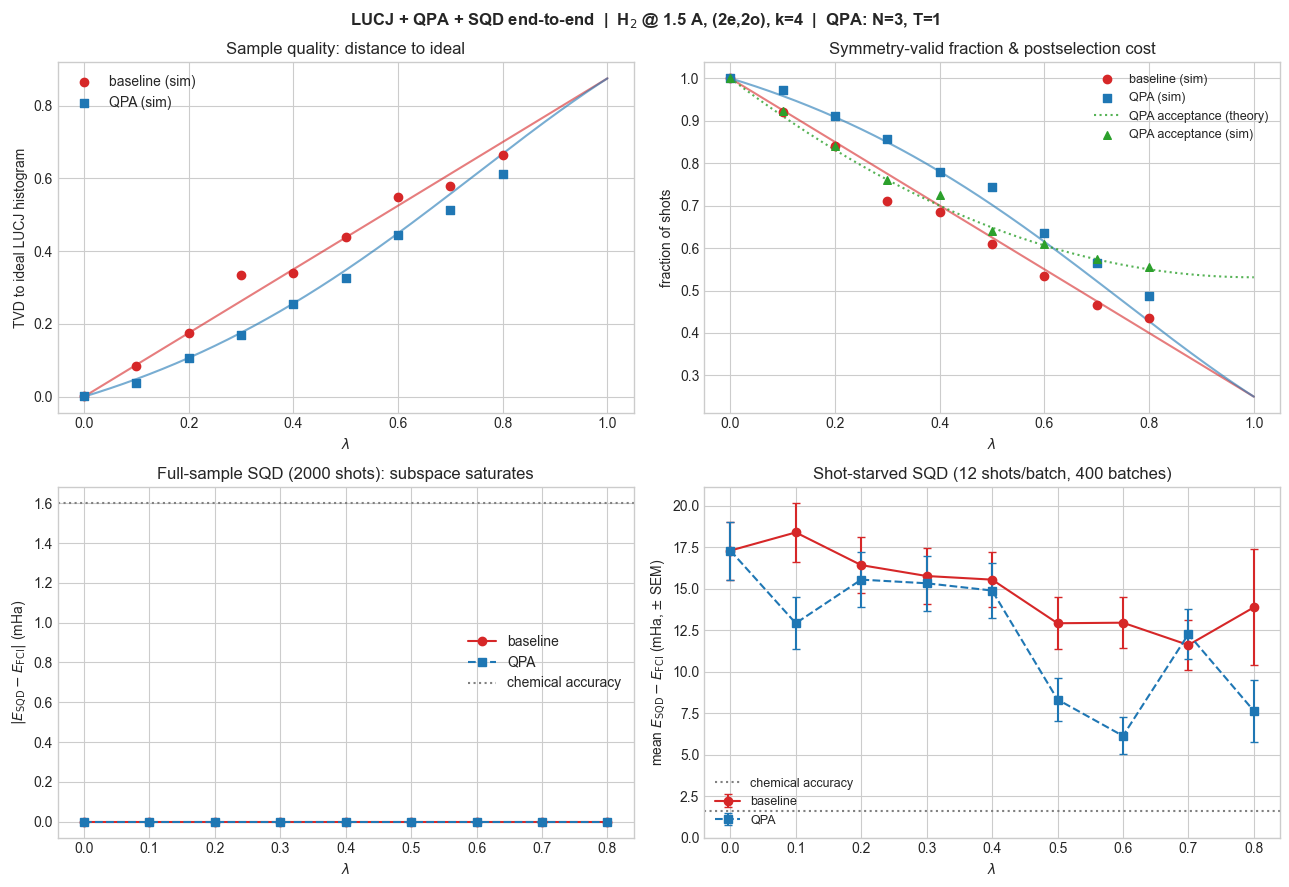

Figure saved -> shared_data/experiment_results/lucj/lucj_qpa_sqd_end_to_end/lucj_qpa_sqd_end_to_end.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

ax = axes[0, 0]
ax.plot(lam_fine, [tvd(dist_theory(l, "baseline"), IDEAL_DIST) for l in lam_fine], "-", color="tab:red", alpha=.6)
ax.plot(lam_fine, [tvd(dist_theory(l, "qpa"), IDEAL_DIST) for l in lam_fine], "-", color="tab:blue", alpha=.6)
ax.scatter(df.lam, df.tvd_base, color="tab:red", zorder=5, label="baseline (sim)")
ax.scatter(df.lam, df.tvd_qpa, color="tab:blue", marker="s", zorder=5, label="QPA (sim)")
ax.set_xlabel(r"$\lambda$"); ax.set_ylabel("TVD to ideal LUCJ histogram")
ax.set_title("Sample quality: distance to ideal"); ax.legend()

ax = axes[0, 1]
ax.plot(lam_fine, [dist_theory(l, "baseline")[VALID_IDX].sum() for l in lam_fine], "-", color="tab:red", alpha=.6)
ax.plot(lam_fine, [dist_theory(l, "qpa")[VALID_IDX].sum() for l in lam_fine], "-", color="tab:blue", alpha=.6)
ax.scatter(df.lam, df.valid_base, color="tab:red", zorder=5, label="baseline (sim)")
ax.scatter(df.lam, df.valid_qpa, color="tab:blue", marker="s", zorder=5, label="QPA (sim)")
ax.plot(lam_fine, acc_th, ":", color="tab:green", alpha=.8, label="QPA acceptance (theory)")
ax.scatter(df.lam, df.acc_emp, color="tab:green", marker="^", s=30, zorder=5, label="QPA acceptance (sim)")
ax.set_xlabel(r"$\lambda$"); ax.set_ylabel("fraction of shots")
ax.set_title("Symmetry-valid fraction & postselection cost"); ax.legend(fontsize=9)

ax = axes[1, 0]
ax.plot(df.lam, 1000 * np.abs(df.e_sqd_base - E_FCI), "o-", color="tab:red", label="baseline")
ax.plot(df.lam, 1000 * np.abs(df.e_sqd_qpa - E_FCI), "s--", color="tab:blue", label="QPA")
ax.axhline(1000 * CHEM_ACC, color="gray", ls=":", label="chemical accuracy")
ax.set_xlabel(r"$\lambda$"); ax.set_ylabel(r"$|E_{\rm SQD} - E_{\rm FCI}|$ (mHa)")
ax.set_title(f"Full-sample SQD ({N_TWIRL * SHOTS} shots): subspace saturates"); ax.legend()

ax = axes[1, 1]
# error bars = standard error of the mean (per-batch errors are bimodal: ~0 or ~E_HF - E_FCI,
# so +/- std would just visualize that bimodality rather than the uncertainty of the mean)
sem = 1000 * df.starved_base_std / np.sqrt(N_BATCHES)
ax.errorbar(df.lam, 1000 * df.starved_base_mean, yerr=sem,
            fmt="o-", color="tab:red", capsize=3, label="baseline")
sem = 1000 * df.starved_qpa_std / np.sqrt(N_BATCHES)
ax.errorbar(df.lam, 1000 * df.starved_qpa_mean, yerr=sem,
            fmt="s--", color="tab:blue", capsize=3, label="QPA")
ax.axhline(1000 * CHEM_ACC, color="gray", ls=":", label="chemical accuracy")
ax.set_ylim(bottom=0)
ax.set_xlabel(r"$\lambda$"); ax.set_ylabel(r"mean $E_{\rm SQD} - E_{\rm FCI}$ (mHa, $\pm$ SEM)")
ax.set_title(f"Shot-starved SQD ({S_BATCH} shots/batch, {N_BATCHES} batches)"); ax.legend(fontsize=9)

fig.suptitle(f"LUCJ + QPA + SQD end-to-end  |  H$_2$ @ {R_BOND} A, (2e,2o), k={K}  |  "
             f"QPA: N={N_COPIES}, T={T_ROUNDS}", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "lucj_qpa_sqd_end_to_end.png"), dpi=130)
plt.show()
print("Figure saved ->", os.path.join(RESULTS_DIR, "lucj_qpa_sqd_end_to_end.png"))

## Takeaways

**Answering the three framing questions:**

1. **What does the output look like?** Bitstring histograms over Jordan–Wigner determinants of one
   4-qubit register. Noise flattens the ideal (≈87% `0101` / 13% `1010`) histogram toward uniform and
   leaks weight onto symmetry-violating strings. The top-left and top-right panels show the damage
   growing linearly in λ for the baseline — and the simulator points sitting on the parameter-free
   theory curves, validating the whole construction.

2. **How does QPA help?** At every λ the QPA points sit *below* the baseline TVD curve and *above*
   the baseline valid-fraction curve: the postselected reserve register really does carry the
   purified state $(\rho_\lambda + \rho_\lambda^2)/(1 + \mathrm{tr}\rho_\lambda^2)$. The cost is the
   acceptance rate (green, ≥ ~50%) and 3× the qubits. This is one round (N=3, T=1) — more copies or
   rounds compound the purification, with the depth budget from `lucj_qpa_depth.ipynb`.

3. **Should SQD be done here?** Yes — it's the natural consumer of QPA's output (Z-basis samples in,
   energy out), and the bottom row shows precisely *how* it should be read at this scale. With
   abundant shots (bottom-left) SQD saturates the 4-determinant space and lands on FCI with or
   without QPA — SQD is *itself* a powerful mitigator, and (2e,2o) is too small for energy alone to
   discriminate. Even in the shot-starved regime (bottom-right) the energy separation is modest and
   non-monotone: QPA sits at-or-below the baseline at low-to-moderate λ, but at large λ the
   baseline is *artificially rescued* by the tiny-system quirk discussed in Step 9 (noise itself
   repopulates the few valid determinants). So at (2e,2o) the **distribution-level metrics (top
   row) are the scale-relevant evidence** of what QPA buys; the energy panels mainly demonstrate
   SQD's own robustness and *why* a larger active space is the right next experiment for an
   energy-level separation.

**Caveats / honest accounting:**
- Comparison is per *accepted* readout sample; QPA pays acceptance × 3× qubits to produce each one.
- The "noise helps baseline SQD" rescue (4 of 16 strings valid) vanishes at scale, where random
  strings are exponentially unlikely to be valid determinants — but at this scale it genuinely
  compresses the energy gap between the pipelines.
- Noise model is register-level global depolarizing injected after a *perfect* prep — the model QPA's
  theory addresses — not gate-level device noise during the prep and amplifier themselves.

**Next steps:** (4e,4o) at k=8 where SQD no longer trivially saturates; gate-level noise via a fake
backend (then the amplifier's own noise enters the budget); `N=5` / `T>1`; and the hardware version
via the unrolled strategy + transpilation notebooks in `experiments/end_to_end_hardware/`.